In [1]:
!pip install seaborn --quiet

In [2]:
import boto3
import pandas as pd
import numpy as np
from io import StringIO

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, RocCurveDisplay
)

import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [3]:
bucket = "ml-team4-adoption-prediction"
key = "San Jose Animal Shelter.csv"

s3 = boto3.client("s3")
obj = s3.get_object(Bucket=bucket, Key=key)

df = pd.read_csv(StringIO(obj["Body"].read().decode("utf-8")))
print(f"Loaded {len(df)} rows, {len(df.columns)} columns")
df.head()

Loaded 6981 rows, 22 columns


,_id,AnimalID,AnimalName,AnimalType,PrimaryColor,SecondaryColor,PrimaryBreed,Sex,DOB,Age,...,IntakeType,IntakeSubtype,IntakeReason,OutcomeDate,OutcomeType,OutcomeSubtype,OutcomeCondition,Crossing,Jurisdiction,LastUpdate
0,1,A0496029,ZOEY,CAT,BLACK,WHITE,DOMESTIC SH,SPAYED,2005-05-01,20.0,...,STRAY,OTC,NaN,2025-08-07,RTO,NaN,MED R,1ST ST AND ALMA,SAN JOSE,2025-08-07
1,2,A0761209,BOLT,DOG,BLACK,TAN,CHIHUAHUA LH,MALE,2008-11-15,17.0,...,STRAY,OTC,NaN,2025-07-19,RTO,NaN,MED M,SAN FELIPE RD/FOWLER RD,SAN JOSE,2025-07-19
2,3,A0778118,ZOEY ROSE,DOG,CHOCOLATE,NaN,LABRADOR RETR,SPAYED,2011-07-16,14.0,...,STRAY,FIELD,NaN,2025-07-29,RTO,NaN,HEALTHY,LEAN AVE X COLVILLE DR,SAN JOSE,2025-07-29
3,4,A0798009,NaN,CAT,TABBY-BRN,NaN,DOMESTIC LH,NEUTERED,2012-03-20,13.0,...,STRAY,MEDVET,NaN,2025-07-31,EUTH,NaN,MED EMERG,INNOVATION DR. / ZANKER RD.,SAN JOSE,2025-09-09
4,5,A0805228,PADDY,CAT,BLACK,WHITE,DOMESTIC MH,NEUTERED,2012-07-26,13.0,...,STRAY,OTC,IP ADOPT,2025-10-05,RTO,NaN,HEALTHY,WATER ST X SYLVANDALE,SAN JOSE,2025-10-05


In [4]:
df.info()
display(df.describe(include="all"))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6981 entries, 0 to 6980
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   _id               6981 non-null   int64  
 1   AnimalID          6981 non-null   object 
 2   AnimalName        3932 non-null   object 
 3   AnimalType        6981 non-null   object 
 4   PrimaryColor      6981 non-null   object 
 5   SecondaryColor    3048 non-null   object 
 6   PrimaryBreed      6981 non-null   object 
 7   Sex               6981 non-null   object 
 8   DOB               6413 non-null   object 
 9   Age               6413 non-null   float64
 10  IntakeDate        6981 non-null   object 
 11  IntakeCondition   6981 non-null   object 
 12  IntakeType        6981 non-null   object 
 13  IntakeSubtype     6946 non-null   object 
 14  IntakeReason      380 non-null    object 
 15  OutcomeDate       6620 non-null   object 
 16  OutcomeType       6622 non-null   object 


,_id,AnimalID,AnimalName,AnimalType,PrimaryColor,SecondaryColor,PrimaryBreed,Sex,DOB,Age,...,IntakeType,IntakeSubtype,IntakeReason,OutcomeDate,OutcomeType,OutcomeSubtype,OutcomeCondition,Crossing,Jurisdiction,LastUpdate
count,6981.000000,6981,3932,6981,6981,3048,6981,6981,6413,6413.000000,...,6981,6946,380,6620,6622,0.0,6539,5813,6895,6981
unique,NaN,6662,2304,5,43,25,173,5,1886,NaN,...,6,18,28,261,11,NaN,11,4002,11,261
top,NaN,A1396581,LUNA,DOG,BLACK,WHITE,DOMESTIC SH,NEUTERED,2024-11-22,NaN,...,STRAY,OTC,IP ADOPT,2025-08-29,ADOPTION,NaN,HEALTHY,MONTEREY RD/UMBARGER RD,SAN JOSE,2026-03-20
freq,NaN,6,39,2313,1900,1886,3518,2133,56,NaN,...,5929,5031,188,63,2381,NaN,3714,43,6496,114
mean,3491.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.940589,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,2015.385447,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.975214,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,1746.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,3491.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,5236.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df = df[df["AnimalType"].isin(["DOG", "PUPPY"])].copy()
print(df["AnimalType"].value_counts())
df.head()

AnimalType
DOG      2313
PUPPY     452
Name: count, dtype: int64


,_id,AnimalID,AnimalName,AnimalType,PrimaryColor,SecondaryColor,PrimaryBreed,Sex,DOB,Age,...,IntakeType,IntakeSubtype,IntakeReason,OutcomeDate,OutcomeType,OutcomeSubtype,OutcomeCondition,Crossing,Jurisdiction,LastUpdate
1,2,A0761209,BOLT,DOG,BLACK,TAN,CHIHUAHUA LH,MALE,2008-11-15,17.0,...,STRAY,OTC,NaN,2025-07-19,RTO,NaN,MED M,SAN FELIPE RD/FOWLER RD,SAN JOSE,2025-07-19
2,3,A0778118,ZOEY ROSE,DOG,CHOCOLATE,NaN,LABRADOR RETR,SPAYED,2011-07-16,14.0,...,STRAY,FIELD,NaN,2025-07-29,RTO,NaN,HEALTHY,LEAN AVE X COLVILLE DR,SAN JOSE,2025-07-29
5,6,A0807591,REX,DOG,BROWN,TAN,MIN PINSCHER,NEUTERED,2009-10-16,16.0,...,STRAY,OTC,NaN,2025-08-06,RESCUE,NaN,HEALTHY,BLOSSOM HILL X LEAN,SAN JOSE,2025-08-06
6,7,A0822868,RED,DOG,TAN,NaN,PIT BULL,MALE,2012-04-26,13.0,...,STRAY,OTC,IP ADOPT,2025-09-27,RESCUE,NaN,MED M,N CAPITOL AVE/TRADEZONE BLVD,SAN JOSE,2025-09-27
7,8,A0868772,PEARL,DOG,WHITE,NaN,CHIHUAHUA SH,FEMALE,2013-02-27,12.0,...,CONFISCATE,ASO,NaN,2025-10-28,RTO,NaN,HEALTHY,NaN,SAN JOSE,2025-10-28


In [6]:
df = df.drop(columns=["_id", "AnimalName", "DOB", "OutcomeSubtype"], errors="ignore")
df.head()

,AnimalID,AnimalType,PrimaryColor,SecondaryColor,PrimaryBreed,Sex,Age,IntakeDate,IntakeCondition,IntakeType,IntakeSubtype,IntakeReason,OutcomeDate,OutcomeType,OutcomeCondition,Crossing,Jurisdiction,LastUpdate
1,A0761209,DOG,BLACK,TAN,CHIHUAHUA LH,MALE,17.0,2025-07-18,MED M,STRAY,OTC,NaN,2025-07-19,RTO,MED M,SAN FELIPE RD/FOWLER RD,SAN JOSE,2025-07-19
2,A0778118,DOG,CHOCOLATE,NaN,LABRADOR RETR,SPAYED,14.0,2025-07-29,MED M,STRAY,FIELD,NaN,2025-07-29,RTO,HEALTHY,LEAN AVE X COLVILLE DR,SAN JOSE,2025-07-29
5,A0807591,DOG,BROWN,TAN,MIN PINSCHER,NEUTERED,16.0,2025-07-22,HEALTHY,STRAY,OTC,NaN,2025-08-06,RESCUE,HEALTHY,BLOSSOM HILL X LEAN,SAN JOSE,2025-08-06
6,A0822868,DOG,TAN,NaN,PIT BULL,MALE,13.0,2025-09-05,HEALTHY,STRAY,OTC,IP ADOPT,2025-09-27,RESCUE,MED M,N CAPITOL AVE/TRADEZONE BLVD,SAN JOSE,2025-09-27
7,A0868772,DOG,WHITE,NaN,CHIHUAHUA SH,FEMALE,12.0,2025-10-21,HEALTHY,CONFISCATE,ASO,NaN,2025-10-28,RTO,HEALTHY,NaN,SAN JOSE,2025-10-28


In [7]:
date_cols = ["IntakeDate", "OutcomeDate", "LastUpdate"]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

df["IsAdoptedFlag"] = (df["OutcomeType"] == "ADOPTION").astype(int)

print(df["IsAdoptedFlag"].value_counts())
df[["IntakeDate", "OutcomeDate", "LastUpdate", "IsAdoptedFlag"]].head()

IsAdoptedFlag
0    1884
1     881
Name: count, dtype: int64


,IntakeDate,OutcomeDate,LastUpdate,IsAdoptedFlag
1,2025-07-18,2025-07-19,2025-07-19,0
2,2025-07-29,2025-07-29,2025-07-29,0
5,2025-07-22,2025-08-06,2025-08-06,0
6,2025-09-05,2025-09-27,2025-09-27,0
7,2025-10-21,2025-10-28,2025-10-28,0


In [8]:
df["DaysInShelter"] = (df["OutcomeDate"] - df["IntakeDate"]).dt.days
df["DaysInShelter"] = df["DaysInShelter"].fillna(99999).astype(int)

display(df[["IntakeDate", "OutcomeDate", "DaysInShelter"]].head())

,IntakeDate,OutcomeDate,DaysInShelter
1,2025-07-18,2025-07-19,1
2,2025-07-29,2025-07-29,0
5,2025-07-22,2025-08-06,15
6,2025-09-05,2025-09-27,22
7,2025-10-21,2025-10-28,7


In [9]:
model_df = df[[
    "AnimalType",
    "PrimaryColor",
    "SecondaryColor",
    "PrimaryBreed",
    "Sex",
    "Age",
    "IntakeCondition",
    "IntakeType",
    "IntakeSubtype",
    "IntakeReason",
    "OutcomeCondition",
    "Crossing",
    "Jurisdiction",
    "DaysInShelter",
    "IsAdoptedFlag"
]].copy()

model_df.head()

,AnimalType,PrimaryColor,SecondaryColor,PrimaryBreed,Sex,Age,IntakeCondition,IntakeType,IntakeSubtype,IntakeReason,OutcomeCondition,Crossing,Jurisdiction,DaysInShelter,IsAdoptedFlag
1,DOG,BLACK,TAN,CHIHUAHUA LH,MALE,17.0,MED M,STRAY,OTC,NaN,MED M,SAN FELIPE RD/FOWLER RD,SAN JOSE,1,0
2,DOG,CHOCOLATE,NaN,LABRADOR RETR,SPAYED,14.0,MED M,STRAY,FIELD,NaN,HEALTHY,LEAN AVE X COLVILLE DR,SAN JOSE,0,0
5,DOG,BROWN,TAN,MIN PINSCHER,NEUTERED,16.0,HEALTHY,STRAY,OTC,NaN,HEALTHY,BLOSSOM HILL X LEAN,SAN JOSE,15,0
6,DOG,TAN,NaN,PIT BULL,MALE,13.0,HEALTHY,STRAY,OTC,IP ADOPT,MED M,N CAPITOL AVE/TRADEZONE BLVD,SAN JOSE,22,0
7,DOG,WHITE,NaN,CHIHUAHUA SH,FEMALE,12.0,HEALTHY,CONFISCATE,ASO,NaN,HEALTHY,NaN,SAN JOSE,7,0


In [10]:
X = model_df.drop(columns=["IsAdoptedFlag"])
y = model_df["IsAdoptedFlag"]

print(X.shape, y.shape)

(2765, 14) (2765,)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print(f"Training set: {len(X_train)} rows")
print(f"Test set: {len(X_test)} rows")
print(f"Adoption rate: {y.mean():.2%}")

Training set: 1935 rows
Test set: 830 rows
Adoption rate: 31.86%


In [12]:
numeric_features = ["Age", "DaysInShelter"]
categorical_features = [col for col in X.columns if col not in numeric_features]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [13]:
lr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ))
])

lr_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

print("Both models trained successfully!")

Both models trained successfully!


In [14]:
results = []

for name, pipe in [("Logistic Regression", lr_pipeline), ("Random Forest", rf_pipeline)]:
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "auc": roc_auc_score(y_test, y_prob)
    }
    results.append(metrics)

    print("=" * 50)
    print(name)
    print("=" * 50)
    print(classification_report(y_test, y_pred, target_names=["Not Adopted", "Adopted"]))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print(f"AUC: {metrics['auc']:.4f}")

results_df = pd.DataFrame(results).sort_values(by="auc", ascending=False)
results_df

Logistic Regression
              precision    recall  f1-score   support

 Not Adopted       0.91      0.89      0.90       566
     Adopted       0.78      0.80      0.79       264

    accuracy                           0.86       830
   macro avg       0.84      0.85      0.84       830
weighted avg       0.87      0.86      0.86       830

Confusion Matrix:
[[505  61]
 [ 52 212]]
AUC: 0.9337
Random Forest
              precision    recall  f1-score   support

 Not Adopted       0.91      0.93      0.92       566
     Adopted       0.84      0.80      0.82       264

    accuracy                           0.89       830
   macro avg       0.87      0.86      0.87       830
weighted avg       0.89      0.89      0.89       830

Confusion Matrix:
[[525  41]
 [ 53 211]]
AUC: 0.9483


,model,accuracy,precision,recall,f1,auc
1,Random Forest,0.886747,0.837302,0.799242,0.817829,0.948332
0,Logistic Regression,0.863855,0.776557,0.803030,0.789572,0.933705


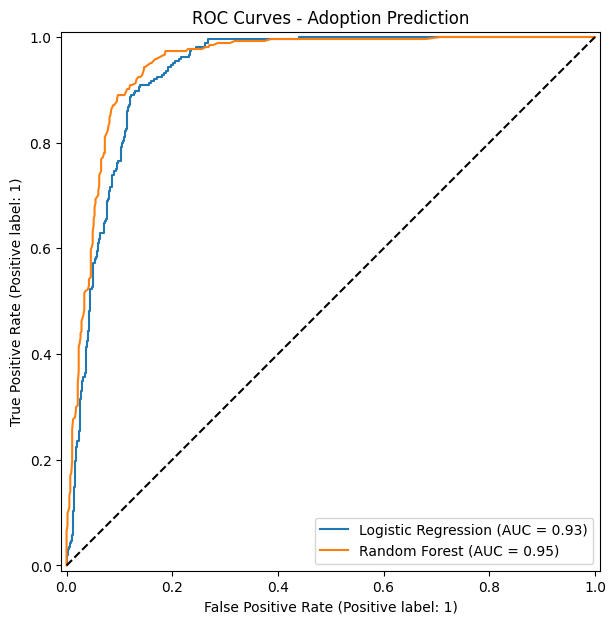

In [15]:
plt.figure(figsize=(7, 7))
ax = plt.gca()

for name, pipe in [("Logistic Regression", lr_pipeline), ("Random Forest", rf_pipeline)]:
    y_prob = pipe.predict_proba(X_test)[:, 1]
    RocCurveDisplay.from_predictions(y_test, y_prob, name=name, ax=ax)

plt.plot([0, 1], [0, 1], "k--", label="Chance")
plt.title("ROC Curves - Adoption Prediction")
plt.show()

In [16]:
best_row = results_df.iloc[0]
best_name = best_row["model"]

if best_name == "Logistic Regression":
    best_pipeline = lr_pipeline
else:
    best_pipeline = rf_pipeline

print("Best model:", best_name)
for col in ["accuracy", "precision", "recall", "f1", "auc"]:
    print(f"{col}: {best_row[col]:.4f}")

Best model: Random Forest
accuracy: 0.8867
precision: 0.8373
recall: 0.7992
f1: 0.8178
auc: 0.9483


In [17]:
local_model_path = "/tmp/adoption_pipeline.joblib"
joblib.dump(best_pipeline, local_model_path)
print(f"Saved model locally to {local_model_path}")

Saved model locally to /tmp/adoption_pipeline.joblib


In [18]:
model_s3_key = "models/adoption_pipeline.joblib"
s3.upload_file(local_model_path, bucket, model_s3_key)

print(f"Model saved to s3://{bucket}/{model_s3_key}")

Model saved to s3://ml-team4-adoption-prediction/models/adoption_pipeline.joblib


In [19]:
metrics_df = results_df.copy()
metrics_local_path = "/tmp/model_metrics.csv"
metrics_df.to_csv(metrics_local_path, index=False)

metrics_s3_key = "models/model_metrics.csv"
s3.upload_file(metrics_local_path, bucket, metrics_s3_key)

print(f"Metrics saved to s3://{bucket}/{metrics_s3_key}")
metrics_df

Metrics saved to s3://ml-team4-adoption-prediction/models/model_metrics.csv


,model,accuracy,precision,recall,f1,auc
1,Random Forest,0.886747,0.837302,0.799242,0.817829,0.948332
0,Logistic Regression,0.863855,0.776557,0.803030,0.789572,0.933705


In [20]:
!pip install pymysql

In [21]:
import os, urllib.request

SSL_CA_URL = "https://truststore.pki.rds.amazonaws.com/global/global-bundle.pem"

if not os.path.exists("./global-bundle.pem"):
    urllib.request.urlretrieve(SSL_CA_URL, "./global-bundle.pem")
    print("Downloaded global-bundle.pem")
else:
    print("global-bundle.pem already present, skipping download")

global-bundle.pem already present, skipping download


In [22]:
import pymysql

connection = pymysql.connect(
    host='adoption-team4.cpeadj3mxeil.us-east-1.rds.amazonaws.com',
    user='admin',
    password='adoptionteam4',
    port=3306,
    ssl_ca = "./global-bundle.pem",
    connect_timeout=10
)

with connection.cursor() as cursor:
    cursor.execute("CREATE DATABASE IF NOT EXISTS `adoption-team4`")
    cursor.execute("SHOW DATABASES")
    print("Databases on RDS:")
    for row in cursor.fetchall():
        print(" ", row[0])
            
print("Connected!")
connection.close()

Databases on RDS:
  adoption-team4
  information_schema
  mysql
  performance_schema
  sys
Connected!


In [23]:
import pymysql

connection = pymysql.connect(
    host='adoption-team4.cpeadj3mxeil.us-east-1.rds.amazonaws.com',
    user='admin',
    password='adoptionteam4',
    database='adoption-team4',
    port=3306,
    ssl_ca='./global-bundle.pem',
    connect_timeout=10
)

cursor = connection.cursor()

# Create table if it does not exist
cursor.execute("""
CREATE TABLE IF NOT EXISTS model_registry (
    id INT AUTO_INCREMENT PRIMARY KEY,
    model_name VARCHAR(255),
    model_location VARCHAR(255),
    accuracy FLOAT,
    precision_score FLOAT,
    recall_score FLOAT,
    f1 FLOAT,
    auc FLOAT,
    created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
)
""")

# Define these before insert
best_name = "Random Forest"

metrics = {
    "accuracy": 0.886747,
    "precision": 0.837302,
    "recall": 0.799242,
    "f1": 0.817829,
    "auc": 0.948332
}

cursor.execute("""
    INSERT INTO model_registry
    (model_name, model_location, accuracy, precision_score, recall_score, f1, auc)
    VALUES (%s, %s, %s, %s, %s, %s, %s)
""", (
    best_name,
    "stored_in_rds_workflow",
    metrics["accuracy"],
    metrics["precision"],
    metrics["recall"],
    metrics["f1"],
    metrics["auc"]
))

connection.commit()
print("Model metadata saved to RDS successfully!")
connection.close()

Model metadata saved to RDS successfully!
